# URFU 2026: Соревнование по классификации

## 1. Библиотеки и настройки

Дефолт и все дела

In [24]:
# !pip -q install pandas numpy matplotlib seaborn scikit-learn kaggle

import os
import shutil
import subprocess
import sys
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 731
DATA_DIR = Path("data")

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 120)

## 2. Загрузка данных

Грузим данные, а не вагоны


In [25]:
COMPETITION = "ur-fu-noise-2026"
DATA_DIR.mkdir(exist_ok=True)

required_files = ["Train.csv", "Target.csv", "Test.csv", "submission.csv"]


def data_is_ready():
    return all((DATA_DIR / filename).exists() for filename in required_files)


def find_kaggle_command():
    kaggle_cmd = shutil.which("kaggle")
    if kaggle_cmd is not None:
        return kaggle_cmd

    scripts_dir = Path(sys.executable).parent / "Scripts"
    candidate = scripts_dir / ("kaggle.exe" if os.name == "nt" else "kaggle")
    if candidate.exists():
        return str(candidate)

    return None


if not data_is_ready():
    print("Данных в папке data нет, пробуем скачать их с Kaggle...")

    kaggle_cmd = find_kaggle_command()
    if kaggle_cmd is None:
        print("Kaggle CLI не найден, устанавливаем пакет kaggle...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
        kaggle_cmd = find_kaggle_command()

    if kaggle_cmd is None:
        raise RuntimeError("Не удалось найти Kaggle CLI.")

    subprocess.run(
        [kaggle_cmd, "competitions", "download", "-c", COMPETITION, "-p", str(DATA_DIR), "--force"],
        check=True,
    )

    for archive_path in DATA_DIR.glob("*.zip"):
        with zipfile.ZipFile(archive_path, "r") as archive:
            archive.extractall(DATA_DIR)
        print(f"Распакован архив: {archive_path}")

missing_files = [filename for filename in required_files if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "Не нашлись файлы данных: " + ", ".join(missing_files)
        + ". Проверьте Kaggle API token или скачайте данные вручную."
    )

train_features = pd.read_csv(DATA_DIR / "Train.csv")
target = pd.read_csv(DATA_DIR / "Target.csv")
test = pd.read_csv(DATA_DIR / "Test.csv")
submission_template = pd.read_csv(DATA_DIR / "submission.csv")

train = train_features.merge(target, on="ID", how="left")

print("Train features:", train_features.shape)
print("Target:", target.shape)
print("Test:", test.shape)
print("Submission template:", submission_template.shape)

display(train.head())
display(test.head())
display(submission_template.head())


Данных в папке data нет, пробую скачать их с Kaggle...
Распакован архив: data\ur-fu-noise-2026.zip
Train features: (7000, 28)
Target: (7000, 2)
Test: (3000, 28)
Submission template: (3000, 2)


,ID,feature 0,feature 1,feature 2,feature 3,feature 4,feature 5,feature 6,feature 7,feature 8,feature 9,feature 10,feature 11,feature 12,feature 13,feature 14,feature 15,feature 16,feature 17,feature 18,feature 19,feature 20,feature 21,feature 22,feature 23,feature 24,feature 25,feature 26,class_new
0,6002,0.284313,4.219830,1.221181,-0.033805,0.954967,3.717548,-5.371620,8,-8.114714,5.265328,2.911401,0.118144,11.258733,13.802743,-0.446961,-1.817709,0.451489,0.484978,5.709929,0.419168,1,5.902307,0.025756,9,0.400968,0.200678,6.044972,2
1,4895,0.688878,-3.151896,-0.084847,0.837584,0.452307,5.007462,1.150248,8,-2.975189,1.613209,3.492624,0.210417,-1.704318,11.661261,-0.564354,0.921713,2.372759,2.378392,2.316058,-0.143171,1,4.830141,3.561733,9,0.025996,0.123487,6.032597,0
2,4072,1.924478,-0.705611,0.658260,0.367463,0.784745,3.570199,2.622817,8,2.182189,0.328124,1.945127,0.110538,3.220057,9.998887,-0.993769,-0.818774,-1.073346,5.225690,9.047253,0.691782,1,4.018763,0.292715,9,0.223886,0.107620,8.970672,2
3,4457,2.012251,2.732572,2.831323,0.470805,-1.067754,5.178344,2.087656,8,-1.931267,3.506177,3.218553,0.169532,5.513759,10.759875,-3.324491,2.346552,-1.771180,1.050520,4.689684,-0.183979,1,4.378999,4.398202,9,0.199916,0.556204,4.974319,1
4,7880,1.405036,-4.750124,-6.526375,-0.770324,0.549478,3.790355,-0.193960,8,-7.969943,1.945758,1.625002,0.136363,2.836082,17.618619,-2.859016,1.117392,0.351779,0.479188,6.697533,2.232350,1,7.818239,3.371134,9,-0.886806,0.576564,4.763733,3


,ID,feature 0,feature 1,feature 2,feature 3,feature 4,feature 5,feature 6,feature 7,feature 8,feature 9,feature 10,feature 11,feature 12,feature 13,feature 14,feature 15,feature 16,feature 17,feature 18,feature 19,feature 20,feature 21,feature 22,feature 23,feature 24,feature 25,feature 26
0,3132,1.392138,-0.091924,-0.861607,-1.168089,0.729858,0.620246,-2.187895,8,-7.675251,4.228064,2.861116,0.129935,-0.129917,8.100336,-3.991496,-2.184939,7.346777,6.186529,4.097432,-1.269949,1,3.083521,3.172888,9,3.640785,0.001478,1.702742
1,4371,2.122404,-0.948922,1.193036,0.971790,0.493626,4.255883,-1.749073,8,0.899573,0.683008,0.469536,0.145760,-5.718098,10.595756,0.339042,-1.313204,4.205691,5.300912,7.235901,-1.127997,1,4.294479,3.108627,9,-0.274482,0.125643,5.355107
2,6647,2.130981,-1.204017,3.480717,-2.275924,0.653080,0.409036,-2.807824,8,7.970245,3.705824,2.798804,0.119928,-0.032577,15.103011,-1.682952,0.301948,-0.107221,7.221782,5.735965,0.758463,1,6.551737,2.545127,9,0.358025,0.554142,4.114993
3,5632,1.556761,-2.857128,2.885403,-0.110835,1.336319,4.275481,3.371328,8,3.727265,5.097581,2.659982,0.205522,-11.212901,13.137824,-1.601750,1.361372,-5.482683,5.964860,2.026291,2.037987,1,5.534718,1.910816,9,-1.761030,0.111407,1.554630
4,9703,1.359874,2.200963,0.896334,-0.422109,-1.178996,1.635622,0.608625,8,-1.808741,4.853391,1.792689,0.188122,-4.968282,21.342482,0.581042,2.446686,-0.992538,6.362811,3.506961,0.683964,1,9.672132,3.973689,9,-2.018466,0.071259,3.625762


,ID,class_new
0,3132,0
1,4371,0
2,6647,0
3,5632,0
4,9703,0


В данных есть `ID`, набор признаков `feature 0 ... 26` и целевая колонка `class_new`, что уже неплохо


## 3. Быстрый обзор данных

Глянем пропуски, дубликаты, баланс классов и константные признаки

In [26]:
TARGET = "class_new"
id_col = "ID"
raw_feature_cols = [col for col in train_features.columns if col != id_col]

overview = pd.DataFrame({
    "dtype": train[raw_feature_cols].dtypes.astype(str),
    "missing": train[raw_feature_cols].isna().sum(),
    "missing_%": (train[raw_feature_cols].isna().mean() * 100).round(2),
    "n_unique": train[raw_feature_cols].nunique(dropna=False),
    "std": train[raw_feature_cols].std(numeric_only=True),
})

constant_features = overview.query("n_unique == 1").index.tolist()
feature_cols = [col for col in raw_feature_cols if col not in constant_features]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Пропусков в train:", int(train[raw_feature_cols].isna().sum().sum()))
print("Пропусков в test:", int(test[raw_feature_cols].isna().sum().sum()))
print("Дубликатов в train:", int(train.duplicated().sum()))
print("Константные признаки:", constant_features)
print("Используем признаков после удаления констант:", len(feature_cols))

display(overview.sort_values(["n_unique", "std"]).head(10))

Train shape: (7000, 29)
Test shape: (3000, 28)
Пропусков в train: 0
Пропусков в test: 0
Дубликатов в train: 0
Константные признаки: ['feature 7', 'feature 20', 'feature 23']
Используем признаков после удаления констант: 24


,dtype,missing,missing_%,n_unique,std
feature 7,int64,0,0.0,1,0.000000
feature 20,int64,0,0.0,1,0.000000
feature 23,int64,0,0.0,1,0.000000
feature 11,float64,0,0.0,7000,0.065233
feature 25,float64,0,0.0,7000,0.179819
feature 0,float64,0,0.0,7000,0.633400
feature 19,float64,0,0.0,7000,0.993175
feature 3,float64,0,0.0,7000,1.001340
feature 4,float64,0,0.0,7000,1.002073
feature 10,float64,0,0.0,7000,1.019982


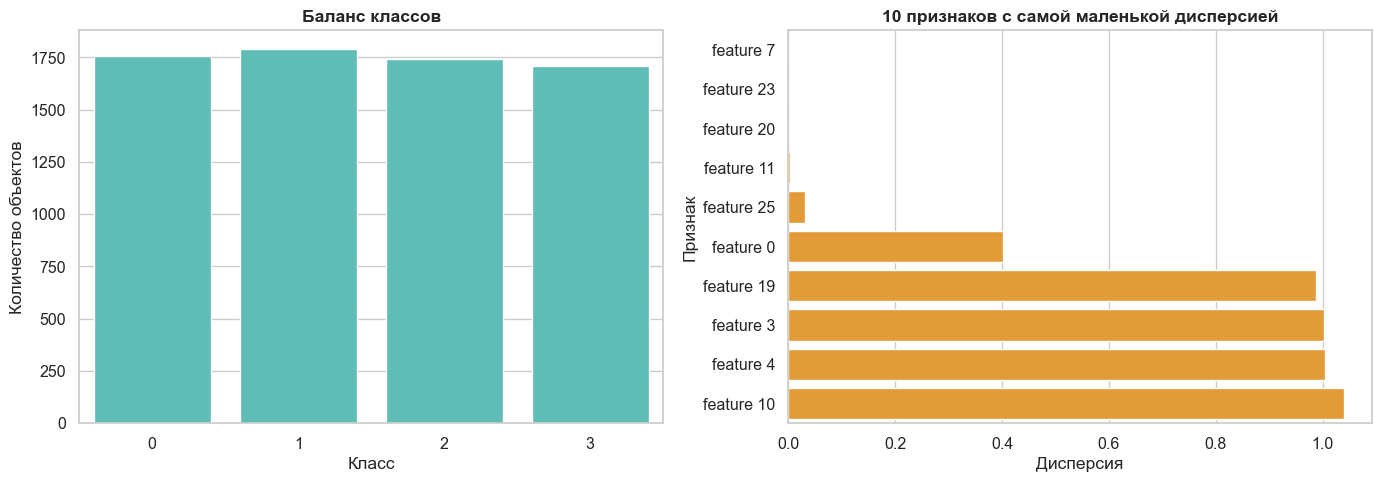

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = train[TARGET].value_counts().sort_index()
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[0], color="#4ECDC4")
axes[0].set_title("Баланс классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество объектов")

variance = train[raw_feature_cols].var(numeric_only=True).sort_values()
sns.barplot(x=variance.values[:10], y=variance.index[:10], ax=axes[1], color="#FF9F1C")
axes[1].set_title("10 признаков с самой маленькой дисперсией")
axes[1].set_xlabel("Дисперсия")
axes[1].set_ylabel("Признак")

plt.tight_layout()
plt.show()

Классы почти идеально сбалансированы: объектов каждого класса примерно поровну. Значит, качество не будет искусственно завышаться за счет предсказания самого частого класса

Пропусков и дубликатов нет, поэтому сложная очистка данных не нужна. Зато есть три константны: `feature 7`, `feature 20`, `feature 23`. Они бесполезны тк одинаковые, поэтому просто уберем их

## 4. Связь признаков с классами

,feature,f_score,p_value
0,feature 2,4.700183,0.002789
1,feature 25,4.558298,0.003402
2,feature 9,3.546158,0.013897
3,feature 13,2.964632,0.030805
4,feature 21,2.868738,0.035086
5,feature 17,1.785217,0.147637
6,feature 19,1.510723,0.209540
7,feature 12,1.335616,0.260818
8,feature 16,1.296986,0.273573
9,feature 15,0.690363,0.557816


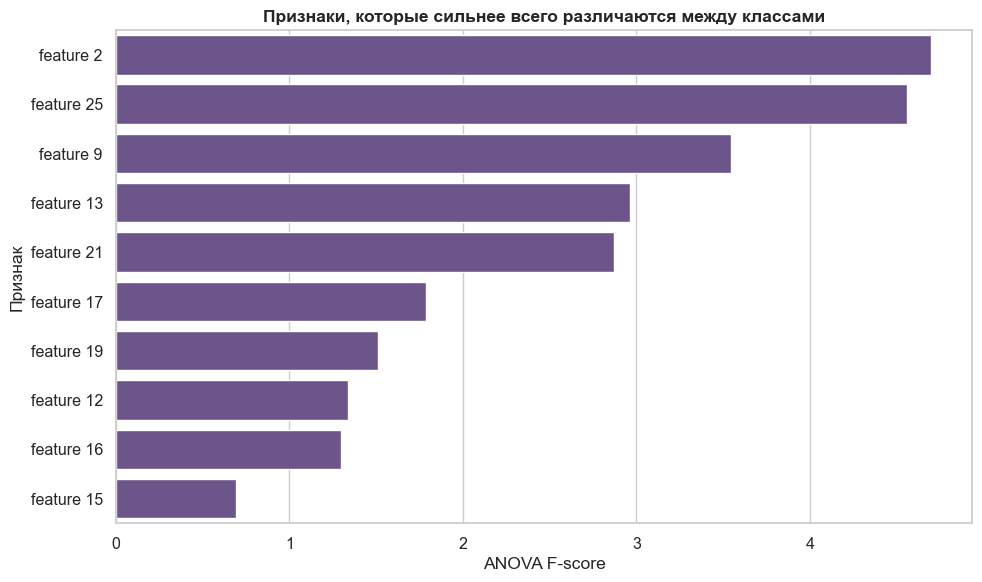

In [28]:
X = train[feature_cols].copy()
y = train[TARGET].copy()
X_test = test[feature_cols].copy()

f_scores, p_values = f_classif(X, y)
feature_score = (
    pd.DataFrame({"feature": feature_cols, "f_score": f_scores, "p_value": p_values})
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

display(feature_score.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_score.head(10), x="f_score", y="feature", color="#6A4C93")
plt.title("Признаки, которые сильнее всего различаются между классами")
plt.xlabel("ANOVA F-score")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

top_features = feature_score.head(6)["feature"].tolist()

Выглядит, как будто многовато шума, кхм, поэтому один бустинг или один лес может оказаться не лучшим решением. Скорее всего, нужно комбинировать


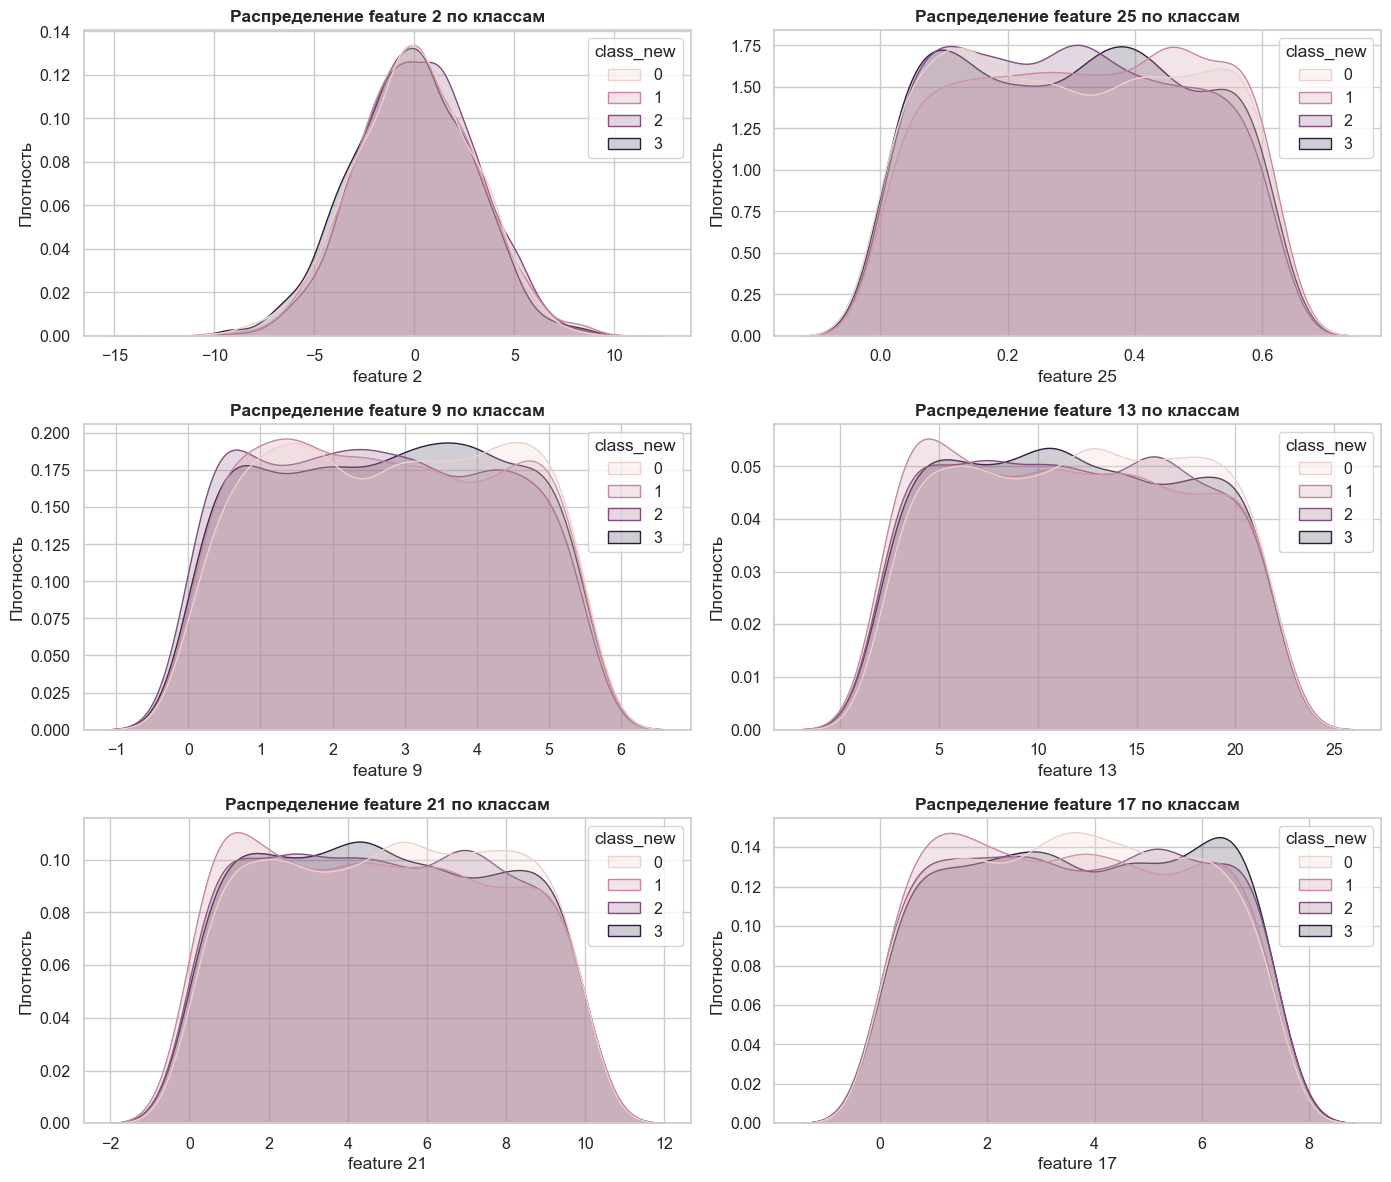

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, top_features):
    sns.kdeplot(
        data=train,
        x=col,
        hue=TARGET,
        common_norm=False,
        fill=True,
        alpha=0.22,
        linewidth=1,
        ax=ax,
    )
    ax.set_title(f"Распределение {col} по классам")
    ax.set_xlabel(col)
    ax.set_ylabel("Плотность")

plt.tight_layout()
plt.show()

Распределения классов сильно накладываются друг на друга. Есть небольшие сдвиги, но нет такого признака, где один класс был бы очевидно отдельно. Качество придется собирать из множества маленьких сигналов

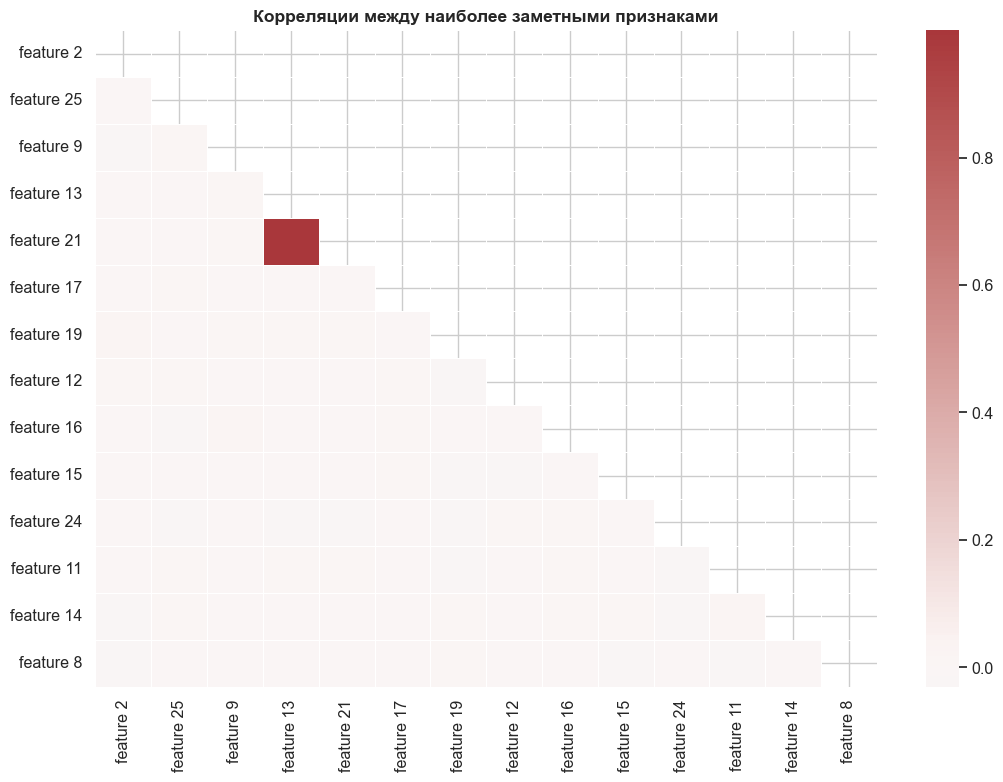

In [30]:
corr_cols = feature_score.head(14)["feature"].tolist()
corr = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, linewidths=0.5)
plt.title("Корреляции между наиболее заметными признаками")
plt.tight_layout()
plt.show()

Сильной линейной зависимости между признаками нет. Это хорошо для ансамбля (?)


## 5. Сравнение моделей

Для начала сравним несколько разных подходов:

- `LDA`
- `GaussianNB`
- `HistGradientBoosting`, `RandomForest`, `ExtraTrees`
- `SVC poly`

Потом объединим их вероятности в weighted soft-voting ансамбль


In [31]:
def make_pipeline(steps):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("var", VarianceThreshold()),
        *steps,
    ])


models = {
    "LDA top-6": make_pipeline([
        ("select", SelectKBest(f_classif, k=6)),
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis()),
    ]),
    "LDA all": make_pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis()),
    ]),
    "GaussianNB": make_pipeline([
        ("model", GaussianNB()),
    ]),
    "HistGB": make_pipeline([
        ("model", HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=15,
            min_samples_leaf=10,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        )),
    ]),
    "ExtraTrees": make_pipeline([
        ("model", ExtraTreesClassifier(
            n_estimators=700,
            min_samples_leaf=1,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "RandomForest": make_pipeline([
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "SVC poly": make_pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=3,
            kernel="poly",
            degree=2,
            gamma="scale",
            coef0=1,
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_proba = {}
rows = []

for name, model in models.items():
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)
    pred = proba.argmax(axis=1)
    score = f1_score(y, pred, average="macro")

    oof_proba[name] = proba
    rows.append({"model": name, "f1_macro_oof": score})
    print(f"{name:12s}: {score:.5f}")

model_scores = pd.DataFrame(rows).sort_values("f1_macro_oof", ascending=False)
display(model_scores)

LDA top-6   : 0.50605
LDA all     : 0.49112
GaussianNB  : 0.48906
HistGB      : 0.50606
ExtraTrees  : 0.48304
RandomForest: 0.48295
SVC poly    : 0.44731


,model,f1_macro_oof
3,HistGB,0.506061
0,LDA top-6,0.506047
1,LDA all,0.491120
2,GaussianNB,0.489058
4,ExtraTrees,0.483042
5,RandomForest,0.482954
6,SVC poly,0.447309


Одиночные модели выглядят не очень: каждая ловит только часть структуры данных

Объединим модели, которые "ошибаются" по разному

## 6. Финальный ансамбль

OOF F1 macro ансамбля: 0.92617

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1758
           1       0.92      0.92      0.92      1791
           2       0.93      0.93      0.93      1742
           3       0.93      0.92      0.93      1709

    accuracy                           0.93      7000
   macro avg       0.93      0.93      0.93      7000
weighted avg       0.93      0.93      0.93      7000



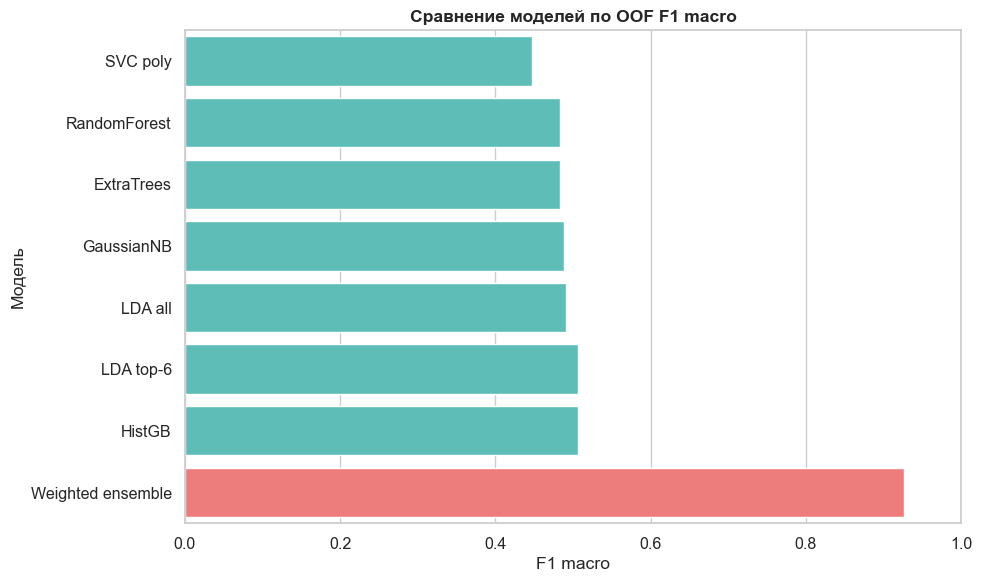

In [32]:
ensemble_weights = {
    "LDA all": 0.3101,
    "SVC poly": 0.2180,
    "LDA top-6": 0.2159,
    "RandomForest": 0.1590,
    "ExtraTrees": 0.0329,
    "HistGB": 0.0309,
    "GaussianNB": 0.0083,
}

weight_sum = sum(ensemble_weights.values())
ensemble_weights = {name: value / weight_sum for name, value in ensemble_weights.items()}

ensemble_oof_proba = np.zeros_like(next(iter(oof_proba.values())))
for name, weight in ensemble_weights.items():
    ensemble_oof_proba += oof_proba[name] * weight

ensemble_oof_pred = ensemble_oof_proba.argmax(axis=1)
ensemble_oof_score = f1_score(y, ensemble_oof_pred, average="macro")

print(f"OOF F1 macro ансамбля: {ensemble_oof_score:.5f}")
print()
print(classification_report(y, ensemble_oof_pred))

plot_scores = pd.concat([
    model_scores,
    pd.DataFrame([{"model": "Weighted ensemble", "f1_macro_oof": ensemble_oof_score}]),
]).sort_values("f1_macro_oof", ascending=True)

plt.figure(figsize=(10, 6))
colors = ["#4ECDC4" if model != "Weighted ensemble" else "#FF6B6B" for model in plot_scores["model"]]
sns.barplot(data=plot_scores, x="f1_macro_oof", y="model", palette=colors)
plt.title("Сравнение моделей по OOF F1 macro")
plt.xlabel("F1 macro")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

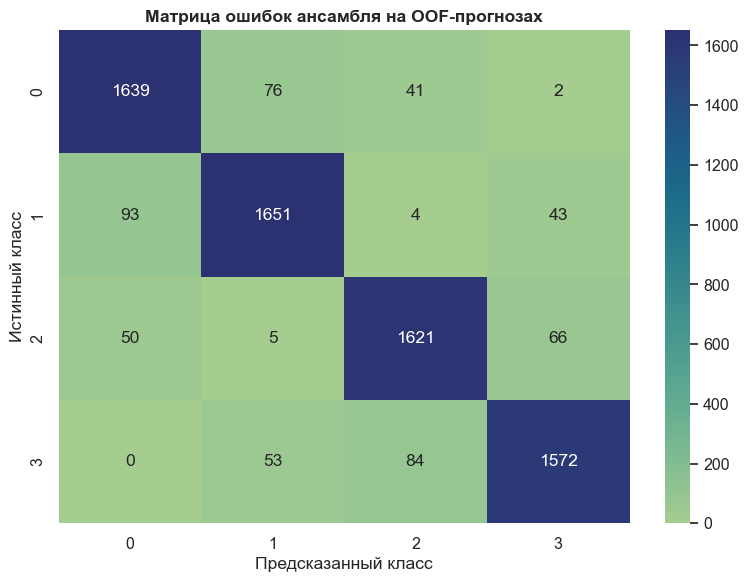

In [33]:
cm = confusion_matrix(y, ensemble_oof_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="crest")
plt.title("Матрица ошибок ансамбля на OOF-прогнозах")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

Ансамбль заметно лучше одиночных моделей - в данных нет одного очевидного сильного признака, поэтому разные модели достают разные слабые сигналы

По матрице ошибок видно, что модель уже не сваливается в один класс и достаточно ровно работает по всем четырем классам. Для `f1` это то, что нужно

## 7. Финальное обучение и submission

Финально обучим

In [34]:
fitted_models = {}
for name, model in models.items():
    fitted_models[name] = clone(model).fit(X, y)

test_proba = np.zeros((len(X_test), y.nunique()))
for name, weight in ensemble_weights.items():
    test_proba += fitted_models[name].predict_proba(X_test) * weight

test_pred = test_proba.argmax(axis=1)

submission = submission_template.copy()
submission[TARGET] = test_pred.astype(int)

output_path = Path("My_Submission.csv")
submission.to_csv(output_path, index=False)
print(f"Файл сохранен: {output_path.resolve()}")

display(submission.head())
display(submission[TARGET].value_counts().sort_index())

Файл сохранен: C:\Users\lomg\Desktop\ml\competition_1\My_Submission.csv


,ID,class_new
0,3132,3
1,4371,0
2,6647,2
3,5632,1
4,9703,3


class_new
0    773
1    751
2    751
3    725
Name: count, dtype: int64

Распределение предсказаний на тесте получилось ровным - это хорошо

,train,test_prediction
class_new,,
0,25.11,25.77
1,25.59,25.03
2,24.89,25.03
3,24.41,24.17


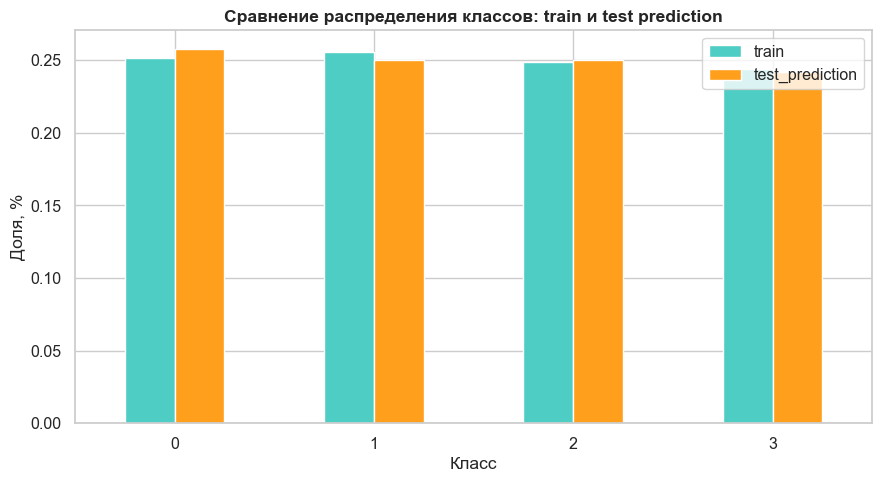

In [35]:
train_dist = y.value_counts(normalize=True).sort_index().rename("train")
test_dist = submission[TARGET].value_counts(normalize=True).sort_index().rename("test_prediction")
dist_compare = pd.concat([train_dist, test_dist], axis=1)

display((dist_compare * 100).round(2))

dist_compare.plot(kind="bar", figsize=(9, 5), color=["#4ECDC4", "#FF9F1C"])
plt.title("Сравнение распределения классов: train и test prediction")
plt.xlabel("Класс")
plt.ylabel("Доля, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Результаты на тестовой выборке

После обучения на всей обучающей выборке применим модель к `Test.csv`.

Итоговый файл: My_Submission.csv
Размер файла: 3000 строк и 2 столбца
Первые строки итогового файла:


,ID,class_new
0,3132,3
1,4371,0
2,6647,2
3,5632,1
4,9703,3
5,2046,3
6,5651,1
7,1188,2
8,5114,3
9,3649,2


Распределение предсказаний по классам:


,train_share_%,test_pred_count,test_pred_share_%
class_new,,,
0,25.11,773,25.77
1,25.59,751,25.03
2,24.89,751,25.03
3,24.41,725,24.17


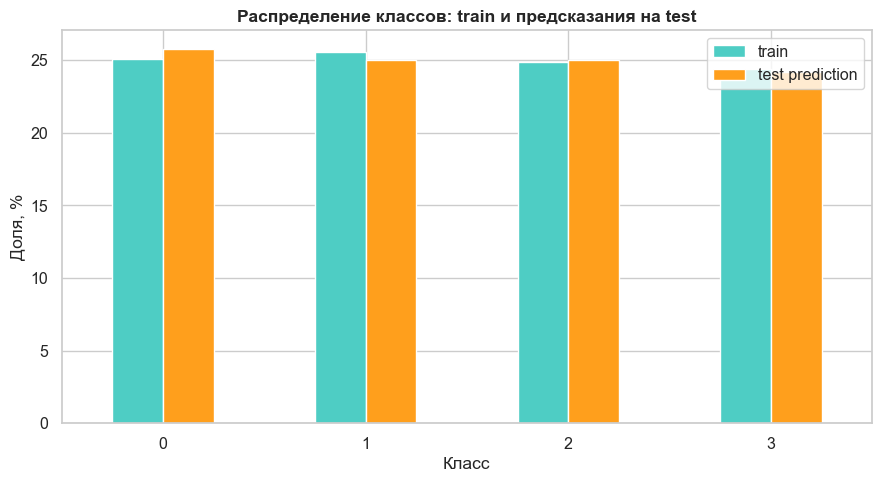

In [36]:
test_results = submission.copy()
test_counts = test_results[TARGET].value_counts().sort_index()
test_share = (test_counts / len(test_results) * 100).round(2)
train_share = (y.value_counts(normalize=True).sort_index() * 100).round(2)

test_summary = pd.DataFrame({
    "train_share_%": train_share,
    "test_pred_count": test_counts,
    "test_pred_share_%": test_share,
})

print(f"Итоговый файл: {output_path}")
print(f"Размер файла: {test_results.shape[0]} строк и {test_results.shape[1]} столбца")
print("Первые строки итогового файла:")
display(test_results.head(10))

print("Распределение предсказаний по классам:")
display(test_summary)

ax = test_summary[["train_share_%", "test_pred_share_%"]].plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4ECDC4", "#FF9F1C"],
)
ax.set_title("Распределение классов: train и предсказания на test")
ax.set_xlabel("Класс")
ax.set_ylabel("Доля, %")
ax.legend(["train", "test prediction"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Распределение предсказаний по классам получилось близким к распределению классов в train, поэтому модель не ушла в перекос и не начала предсказывать почти всё одним классом

## 9. Результат




In [20]:
# !pip install -q kaggle
#
# COMPETITION = "ur-fu-noise-2026"
# SUBMISSION_FILE = "My_Submission.csv"
# MESSAGE = "final notebook submission"
#
# !kaggle competitions submit -c {COMPETITION} -f {SUBMISSION_FILE} -m "{MESSAGE}"


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Successfully submitted to UrFU Noise 2026



  0%|          | 0.00/23.2k [00:00<?, ?B/s]
 69%|██████▉   | 16.0k/23.2k [00:00<00:00, 21.5kB/s]
100%|██████████| 23.2k/23.2k [00:01<00:00, 14.4kB/s]


Что то типо решения с цифрой 0.93622

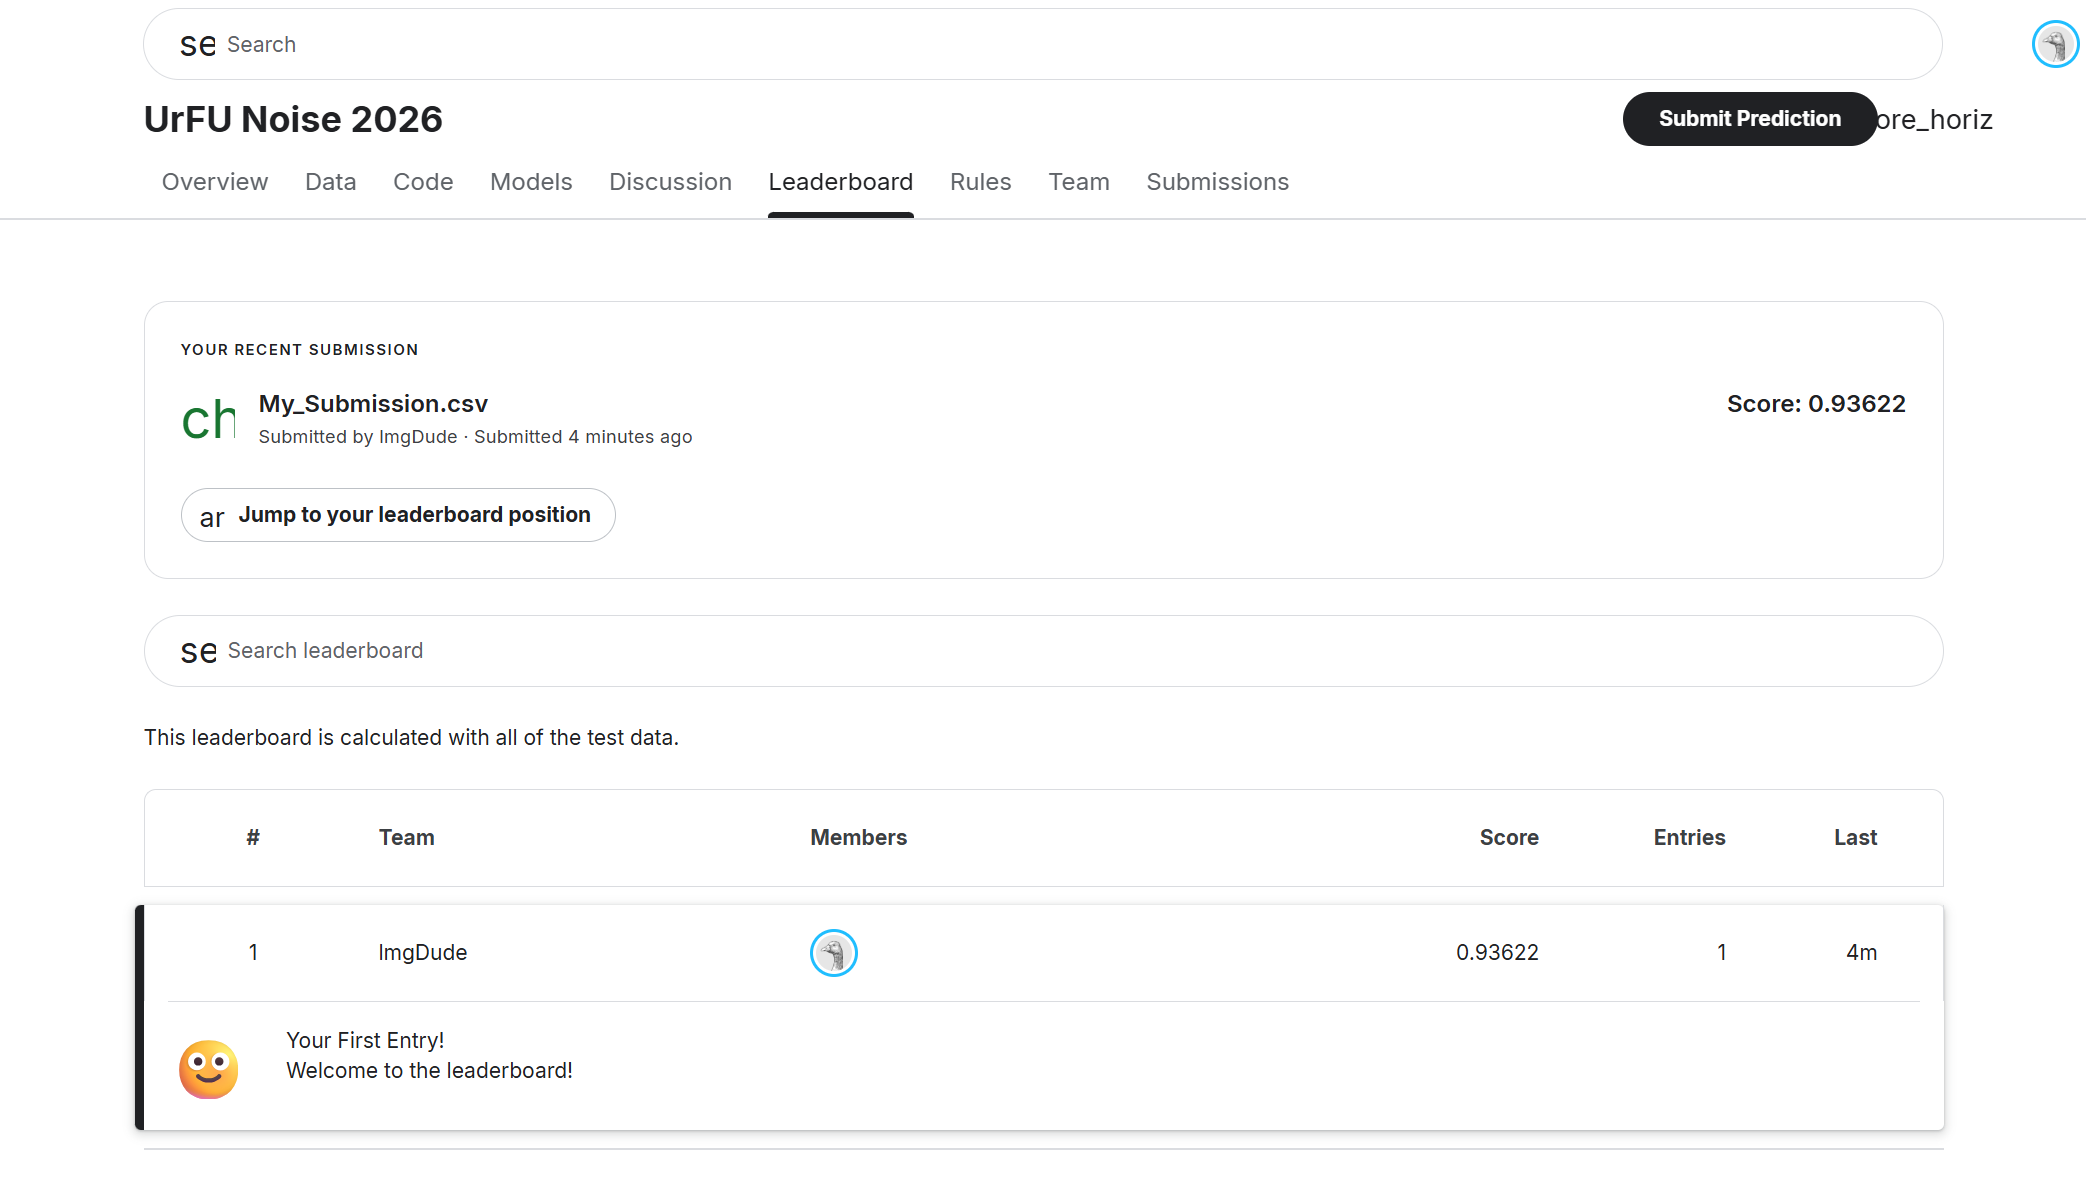